**Contexte**


Une entreprise souhaite développer un système d’intelligence artificielle capable de reconnaître
automatiquement le type de déchet présent sur une photographie afin d'améliorer le tri des
déchets.
Le modèle devra classer chaque image dans l'une des catégories suivantes :

``cardboard`` : cartons ondulés, cartons plats, …

``plastic`` : bouteilles, emballages plastiques...

``paper`` : feuilles, journaux...

``glass`` : bouteilles et objets en verre...

``metal`` : canettes, boîtes métalliques...

``trash`` : emballages bonbons, tasses jetables, ...

Le problème est que les images collectées proviennent de plusieurs sources. Elles ne sont donc pas
homogènes : dimensions différentes ; formats différents ; images RGB et grayscale ; certaines images
sont trop petites ; certaines images sont corrompues ; quelques images sont vides ; images
dupliquées ; quelques images placées dans le mauvais dossier ; classes déséquilibrées.
L'objectif de l'atelier est donc de construire un jeu de données images propre et homogène, prêt à
être utilisé pour entraîner un modèle de Machine Learning ou de Deep Learning.

**Objectifs pédagogiques**

À la fin de l'atelier, l'apprenant devra être capable de :
1) explorer un dataset d'images ;
2) détecter les images problématiques ;
3) détecter les différences de résolution ;
4) détecter les différences de nombre de canaux ;
5) identifier les images trop petites ;
6) détecter les doublons ;
7) identifier les classes déséquilibrées ;
8) redimensionner les images ;
9) normaliser les valeurs des pixels ;
10) uniformiser les canaux ;
11) appliquer de la data augmentation

In [43]:
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np
import hashlib

# alors pour cette atelier je vais utiliser les variables os path pour mieux gérer les chemins de fichiers et dossiers

import os
from pathlib import Path
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

# Chemins du projet : on utilise Path (plus lisible/robuste que des chaînes de caractères concaténées)
RAW_DIR = Path("../data/raw")
CLEANED_DIR = Path("../data/cleaned")
REPORTS_DIR = Path("../reports")
CLASSES = sorted([d.name for d in RAW_DIR.iterdir() if d.is_dir()])

print("Les classes détectées :", CLASSES)

Les classes détectées : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


**Partie 1 – Exploration du dataset**

Développer un programme Python capable de récupérer, pour chaque image, son nom, sa classe,
son format, son mode, sa largeur, sa hauteur, l’écart-type de ses pixels, son nombre de canaux et sa
taille.

``NB :`` prendre en charge aussi les fichiers corrompus

In [44]:
def explorer_image(chemin, classe):
    """
    Ouvre une image et retourne un dictionnaire avec toutes ses caractéristiques.
    Si l'image est corrompue (illisible), retourne un dictionnaire avec des valeurs manquantes
    et corrompue=True, SANS lever d'exception (grâce au try/except).
    """
    fiche = {
        "nom": chemin.name,
        "classe": classe,
        "chemin": str(chemin),
    }


    try:
        fiche["taille_octets"] = chemin.stat().st_size
    except OSError:
        fiche["taille_octets"] = None

    try:
        with Image.open(chemin) as img:
            img.load()

            fiche["corrompue"] = False
            fiche["format"] = img.format               
            fiche["mode"] = img.mode                    
            fiche["largeur"], fiche["hauteur"] = img.size
            fiche["nb_canaux"] = len(img.getbands())    

            arr = np.array(img.convert("L"))
            fiche["std_pixels"] = float(arr.std())

    except Exception as e:
        fiche["corrompue"] = True
        fiche["format"] = None
        fiche["mode"] = None
        fiche["largeur"] = None
        fiche["hauteur"] = None
        fiche["nb_canaux"] = None
        fiche["std_pixels"] = None
        fiche["erreur"] = str(e)

    return fiche


fiches = []
for classe in CLASSES:
    dossier_classe = RAW_DIR / classe
    for chemin_image in sorted(dossier_classe.iterdir()):
        fiches.append(explorer_image(chemin_image, classe))

audit = pd.DataFrame(fiches)
print(f"{len(audit)} images explorées au total.")
audit.head(10)


1032 images explorées au total.


,nom,classe,chemin,taille_octets,corrompue,format,mode,largeur,hauteur,nb_canaux,std_pixels,erreur
0,cardboard1.jpg,cardboard,..\data\raw\cardboard\cardboard1.jpg,17333,False,JPEG,RGB,512.0,384.0,3.0,31.875892,NaN
1,cardboard10.jpg,cardboard,..\data\raw\cardboard\cardboard10.jpg,21683,False,JPEG,RGB,512.0,384.0,3.0,38.799907,NaN
2,cardboard100.jpg,cardboard,..\data\raw\cardboard\cardboard100.jpg,14884,False,JPEG,RGB,512.0,384.0,3.0,44.498372,NaN
3,cardboard101.jpg,cardboard,..\data\raw\cardboard\cardboard101.jpg,14289,False,JPEG,RGB,512.0,384.0,3.0,68.561937,NaN
4,cardboard102.jpg,cardboard,..\data\raw\cardboard\cardboard102.jpg,18015,False,JPEG,RGB,512.0,384.0,3.0,45.320633,NaN
5,cardboard103.jpg,cardboard,..\data\raw\cardboard\cardboard103.jpg,21104,False,JPEG,RGB,512.0,384.0,3.0,35.713359,NaN
6,cardboard104.jpg,cardboard,..\data\raw\cardboard\cardboard104.jpg,17225,False,JPEG,RGB,512.0,384.0,3.0,31.949912,NaN
7,cardboard105.jpg,cardboard,..\data\raw\cardboard\cardboard105.jpg,24417,False,JPEG,RGB,512.0,384.0,3.0,42.665779,NaN
8,cardboard106.jpg,cardboard,..\data\raw\cardboard\cardboard106.jpg,26388,False,JPEG,RGB,512.0,384.0,3.0,52.755686,NaN
9,cardboard107.jpg,cardboard,..\data\raw\cardboard\cardboard107.jpg,25368,False,JPEG,RGB,512.0,384.0,3.0,34.045471,NaN


j'ai maintenant un tableau `audit` avec **une ligne par image** et toutes les informations
demandées. C'est ce tableau qui va me servir de base à absolument toutes les parties suivantes
(Parties 2 à 8) : plutôt que de reparcourir le dossier d'images à chaque question, on filtre
simplement ce DataFrame.

**Partie 2 – Détecter les images corrompues**

**Définition d'image corrompu**

C'est un fichier qui *prétend* être une image (souvent via son extension `.jpg`, `.png`...) mais
dont les données sont endommagées : en-tête invalide, fichier tronqué (coupé avant la fin), ou
contenu binaire aléatoire. Pillow lève alors une exception quand on essaie de le lire.

In [45]:
def est_corrompue(chemin):
    """
    Retourne True si l'image ne peut pas être ouverte ET intégralement décodée par Pillow.

    On fait DEUX passes volontairement :
      1) img.verify() : une vérification rapide de l'intégrité du fichier (structure interne),
         sans décoder complètement les pixels.
      2) Image.open(...).load() : un rechargement complet avec décodage de tous les pixels.

    Pourquoi deux passes et pas une seule ?
    Parce que .verify() a un effet de bord : une fois appelée, l'objet Image ne peut plus être
    réutilisé pour d'autres opérations. Et surtout, certains fichiers légèrement endommagés
    passent .verify() (la structure globale semble correcte) mais échouent au décodage complet
    des pixels avec .load(). Faire les deux donne une détection plus fiable qu'une seule des deux.
    """
    try:
        with Image.open(chemin) as img:
            img.verify()
        with Image.open(chemin) as img:
            img.load()
        return False
    except Exception:
        return True


audit["corrompue_v2"] = audit["chemin"].apply(lambda p: est_corrompue(Path(p)))
assert (audit["corrompue"] == audit["corrompue_v2"]).all(), "Incohérence entre les deux détections !"
audit = audit.drop(columns=["corrompue_v2"])

images_corrompues = audit[audit["corrompue"]]
print(f"Nombre d'images corrompues détectées : {len(images_corrompues)}")
images_corrompues[["classe", "nom", "erreur"]]

Nombre d'images corrompues détectées : 6


,classe,nom,erreur
147,cardboard,cardboard83.jpg,cannot identify image file '..\\data\\raw\\car...
326,glass,glass74.jpg,Truncated File Read
446,metal,metal48.jpg,cannot identify image file '..\\data\\raw\\met...
633,paper,paper213.jpg,cannot identify image file '..\\data\\raw\\pap...
791,plastic,plastic13.jpg,cannot identify image file '..\\data\\raw\\pla...
1004,trash,trash3.jpg,cannot identify image file '..\\data\\raw\\tra...


**Résultat :** quelques images corrompues sont bien présentes dans le dataset (fichiers dont le
contenu binaire ne correspond pas à une image valide, malgré une extension `.jpg`). Elles seront
exclues du dataset nettoyé (`cleaned/`), car un modèle de Machine Learning ne peut rien apprendre
d'un fichier illisible.

**Partie 3 – Détecter les images vides**

Écrire et se servir d’une fonction qui détecte les images vides : image entièrement noire, image
entièrement blanche ou image dont les pixels présentent très peu de variation.

### L'idée : réutiliser l'écart-type calculé en Partie 1
On l'a vu en Pillow 101 : une image convertie en niveaux de gris (`convert("L")`) donne un tableau
numpy de valeurs entre 0 (noir) et 255 (blanc). Si **tous les pixels ont presque la même valeur**
(que ce soit 0, 255, ou n'importe quelle autre valeur uniforme), l'écart-type de ce tableau sera
proche de 0. C'est exactement notre définition d'une "image vide" : peu importe si elle est noire,
blanche ou grise unie, ce qui compte c'est l'**absence de variation**.

On choisit un seuil (`SEUIL_ECART_TYPE_VIDE = 5`) : en dessous de ce seuil, on considère l'image
comme quasi vide. Ce seuil est un choix pédagogique raisonnable — dans un vrai projet, on
l'ajusterait en observant plusieurs exemples limites.

In [46]:
SEUIL_ECART_TYPE_VIDE = 5

def est_quasi_vide(chemin, seuil=SEUIL_ECART_TYPE_VIDE):
    """
    Retourne True si l'image est quasiment uniforme (noire, blanche, ou toute autre couleur unie),
    c'est-à-dire si l'écart-type de ses pixels (en niveaux de gris) est en dessous du seuil.
    Retourne aussi False si l'image est corrompue (on ne peut pas juger une image qu'on ne peut
    pas ouvrir : ce cas est déjà géré par est_corrompue()).
    """
    try:
        with Image.open(chemin) as img:
            img.load()
            arr = np.array(img.convert("L"))
            return float(arr.std()) < seuil
    except Exception:
        return False


audit["quasi_vide"] = (~audit["corrompue"]) & (audit["std_pixels"] < SEUIL_ECART_TYPE_VIDE)

images_vides = audit[audit["quasi_vide"]]
print(f"Nombre d'images quasi vides détectées : {len(images_vides)}")
images_vides[["classe", "nom", "std_pixels"]]

Nombre d'images quasi vides détectées : 4


,classe,nom,std_pixels
167,cardboard,image-blanche-512x384.jpg,1.132032
355,glass,image-noire-512x384.png,0.000000
357,metal,image-blanche-512x384.jpg,1.132032
358,metal,image-noire-512x384.png,0.000000


**Partie 4 – Détecter les différences de résolution**

1) Déterminer la résolution minimale, la résolution maximale, les résolutions les plus
fréquentes et le nombre d'images par résolution.

In [47]:
# On travaille uniquement sur les images valides (non corrompues)
audit_valide = audit[~audit["corrompue"]].copy()

audit_valide["resolution"] = (
    audit_valide["largeur"].astype(int).astype(str)
    + "x"
    + audit_valide["hauteur"].astype(int).astype(str)
)

audit_valide["nb_pixels"] = audit_valide["largeur"] * audit_valide["hauteur"]

ligne_min = audit_valide.loc[audit_valide["nb_pixels"].idxmin()]
ligne_max = audit_valide.loc[audit_valide["nb_pixels"].idxmax()]

print(f"Résolution minimale : {ligne_min['resolution']}  ({ligne_min['classe']}/{ligne_min['nom']})")
print(f"Résolution maximale : {ligne_max['resolution']}  ({ligne_max['classe']}/{ligne_max['nom']})")
print()

frequence_resolutions = audit_valide["resolution"].value_counts()
print(f"Nombre de résolutions distinctes : {frequence_resolutions.shape[0]}")
print()
print("Résolutions les plus fréquentes :")
frequence_resolutions


Résolution minimale : 32x32  (cardboard/cardboard22.jpg)
Résolution maximale : 512x384  (cardboard/cardboard1.jpg)

Nombre de résolutions distinctes : 4

Résolutions les plus fréquentes :


resolution
512x384    1013
32x32         5
48x32         4
40x40         4
Name: count, dtype: int64

2) On décide qu'une image doit avoir au minimum 64 × 64 pixels. Identifions toutes les images
ne respectant pas cette contrainte.

In [48]:
RESOLUTION_MIN = 64  # en pixels, sur chaque dimension

audit_valide["trop_petite"] = (
    (audit_valide["largeur"] < RESOLUTION_MIN) | (audit_valide["hauteur"] < RESOLUTION_MIN)
)

images_trop_petites = audit_valide[audit_valide["trop_petite"]]
print(f"Nombre d'images trop petites (< {RESOLUTION_MIN}x{RESOLUTION_MIN}) : {len(images_trop_petites)}")
images_trop_petites[["classe", "nom", "largeur", "hauteur"]].sort_values(["largeur", "hauteur"])

Nombre d'images trop petites (< 64x64) : 13


,classe,nom,largeur,hauteur
77,cardboard,cardboard22.jpg,32.0,32.0
268,glass,glass21.jpg,32.0,32.0
270,glass,glass23.jpg,32.0,32.0
413,metal,metal2.jpg,32.0,32.0
507,paper,paper10.jpg,32.0,32.0
133,cardboard,cardboard70.jpg,40.0,40.0
171,glass,glass100.jpg,40.0,40.0
421,metal,metal26.jpg,40.0,40.0
707,paper,paper54.jpg,40.0,40.0
20,cardboard,cardboard117.jpg,48.0,32.0


**Pourquoi une contrainte de taille minimale ?** Une image de 32×32 pixels contient beaucoup
moins d'information visuelle qu'une image de 512×384 : une fois redimensionnée à 224×224 (Partie 9),
elle serait essentiellement composée de pixels "inventés" par l'algorithme d'interpolation plutôt
que de vrais détails, ce qui peut nuire à l'apprentissage du modèle. On les retire donc du dataset
nettoyé.

In [49]:
# On reporte la colonne trop_petite / resolution / nb_pixels dans le DataFrame audit principal
audit = audit.merge(
    audit_valide[["chemin", "resolution", "nb_pixels", "trop_petite"]],
    on="chemin", how="left"
)

print("report avec succée")

report avec succée


**Partie 5 – Détecter les différents canaux**

Déterminer le nombre d'images selon leur nombre de canaux.

In [50]:
repartition_canaux = audit_valide["nb_canaux"].value_counts().sort_index()
print("Nombre d'images par nombre de canaux :")
print(repartition_canaux)
print()

repartition_modes = audit_valide["mode"].value_counts()
print("Nombre d'images par mode Pillow :")
print(repartition_modes)

Nombre d'images par nombre de canaux :
nb_canaux
1.0       2
3.0    1006
4.0      18
Name: count, dtype: int64

Nombre d'images par mode Pillow :
mode
RGB     1006
RGBA      18
P          2
Name: count, dtype: int64


je l'avais oublier ici c'es la detections des images en grille

In [59]:
def diff_moyenne_canaux(chemin):
    """
    Calcule un indicateur de "grisitude" : la différence moyenne entre les canaux R, G et B.
    Proche de 0 => les 3 canaux sont quasi identiques => l'image est visuellement en niveaux de gris,
    même si elle est techniquement stockée en RGB.
    """
    try:
        with Image.open(chemin) as img:
            img.load()
            arr = np.array(img.convert("RGB")).astype(np.int16)
            diff_rg = np.abs(arr[:, :, 0] - arr[:, :, 1]).mean()
            diff_gb = np.abs(arr[:, :, 1] - arr[:, :, 2]).mean()
            return float(diff_rg + diff_gb)
    except Exception:
        return np.nan


audit_valide["diff_canaux_rgb"] = audit_valide["chemin"].apply(diff_moyenne_canaux)

SEUIL_GRIS = 2.0
audit_valide["grayscale_visuel"] = (
    (audit_valide["diff_canaux_rgb"] < SEUIL_GRIS) & (~audit_valide["quasi_vide"])
)

images_grises = audit_valide[audit_valide["grayscale_visuel"]]
print(f"Images visuellement en niveaux de gris (mais stockées en RGB/RGBA) : {len(images_grises)}")
images_grises[["classe", "nom", "mode", "diff_canaux_rgb"]].head(10)

Images visuellement en niveaux de gris (mais stockées en RGB/RGBA) : 17


,classe,nom,mode,diff_canaux_rgb
45,cardboard,cardboard13v.png,RGBA,0.0
81,cardboard,cardboard25g.png,RGBA,0.0
93,cardboard,cardboard35tg.png,RGBA,0.0
109,cardboard,cardboard4g.png,RGBA,0.0
112,cardboard,cardboard50rg.png,RGBA,0.0
149,cardboard,cardboard85g.png,RGBA,0.0
180,glass,glass109g.png,RGBA,0.0
190,glass,glass117g.png,RGBA,0.0
193,glass,glass11g.png,RGBA,0.0
266,glass,glass20g.png,RGBA,0.0


On garde cette information de côté (`grayscale_visuel`) : contrairement aux images corrompues,
vides, trop petites ou dupliquées, une image en niveaux de gris **n'est pas forcément un problème
en soi** (elle reste exploitable après uniformisation des canaux en Partie 10) — mais c'est une
information utile à faire figurer dans notre rapport d'audit final, comme demandé dans l'énoncé
(`"Images grayscale"` dans `audit_images.csv`).

**Partie 6 – Détecter les doublons**

Écrire et se servir d’une fonction qui détecte les doublons
NB : Deux fichiers différents peuvent contenir exactement la même image.

### Pourquoi ne peut-on pas simplement comparer les noms de fichiers ?
Parce que deux fichiers `metal35.jpg` et `metal35rt.jpg` peuvent avoir des noms totalement
différents tout en contenant exactement la même photo (un simple renommage, ou une copie
accidentelle). Il faut donc comparer le **contenu visuel** des images, pas leurs noms.

### La stratégie : un hash des pixels
On ne peut pas non plus comparer directement les **octets bruts** du fichier : deux fichiers
peuvent contenir la même image mais être enregistrés dans des formats différents (`.jpg` vs
`.png`) ou avec une compression légèrement différente, et donc avoir des octets différents tout en
étant visuellement identiques.

La solution : on **décode** chaque image avec Pillow, on la redimensionne à une petite taille fixe
(64×64) pour neutraliser d'éventuelles différences mineures de résolution, on convertit en RGB pour
neutraliser les différences de mode, puis on calcule une **empreinte (hash)** du résultat avec
`hashlib.md5()`. Deux images visuellement identiques produiront alors exactement le même hash, même
si leurs fichiers d'origine sont différents.

In [51]:
def hash_pixels(chemin, taille=(64, 64)):
    """
    Calcule une empreinte (hash MD5) du CONTENU VISUEL d'une image, indépendamment de son nom de
    fichier, son format d'origine ou son mode. Deux images identiques à l'œil donneront le même hash.
    """
    try:
        with Image.open(chemin) as img:
            img.load()
            img_normalisee = img.convert("RGB").resize(taille)
            return hashlib.md5(img_normalisee.tobytes()).hexdigest()
    except Exception:
        return None


audit_valide["hash_pixels"] = audit_valide["chemin"].apply(hash_pixels)

occurrences_par_hash = audit_valide["hash_pixels"].value_counts()
hashs_dupliques = occurrences_par_hash[occurrences_par_hash > 1].index

audit_valide["est_doublon"] = audit_valide["hash_pixels"].isin(hashs_dupliques)

print(f"Nombre de groupes de doublons détectés : {len(hashs_dupliques)}")
print(f"Nombre total de fichiers concernés par un doublon : {audit_valide['est_doublon'].sum()}")

Nombre de groupes de doublons détectés : 15
Nombre total de fichiers concernés par un doublon : 30


**Interprétation :** on retrouve bien des doublons **au sein d'une même classe** (ex. deux
photos de métal identiques mais enregistrées sous deux noms différents), mais aussi — et c'est bien
plus problématique — des doublons **entre deux classes différentes** : la même photo se retrouve
dans deux dossiers de classes distincts. C'est un signal très important qu'on va exploiter dans la
partie suivante pour repérer les images mal classées.

**Stratégie de nettoyage retenue :** pour chaque groupe de doublons, on ne garde qu'**une seule
copie** (la première rencontrée, en parcourant les classes puis les noms de fichiers par ordre
alphabétique) et on retire toutes les autres du dataset nettoyé.

In [52]:
# On marque, pour chaque groupe, quelle est la "première occurrence" à conserver
audit_valide = audit_valide.sort_values(["classe", "nom"]).reset_index(drop=True)
audit_valide["premiere_occurrence"] = ~audit_valide.duplicated(subset="hash_pixels", keep="first")
audit_valide["doublon_a_retirer"] = audit_valide["est_doublon"] & (~audit_valide["premiere_occurrence"])

print(f"Doublons à retirer du dataset nettoyé : {audit_valide['doublon_a_retirer'].sum()}")
audit_valide[audit_valide["doublon_a_retirer"]][["classe", "nom", "hash_pixels"]]



Doublons à retirer du dataset nettoyé : 15


,classe,nom,hash_pixels
354,glass,image-violet-512x384.gif,911edf8eabb13dd44886ff144ecef1dc
355,metal,image-blanche-512x384.jpg,18115c5cc00d08a5cb6b5bfb0dadefb9
356,metal,image-noire-512x384.png,4072783b8efb99a9e5817067d68f61c6
386,metal,metal125po.jpg,0ba1844a14b63a7dae0270fd7633c152
430,metal,metal35rt.jpg,15bc6c7e9e43da7eb402d9ee24bc45bc
493,metal,metal91.jpg,62de4c0826999ad0780fd7a5263734e9
502,metal,metalyu65.jpg,8e4d91085682e15f87369b0351a92666
639,paper,paper221kl.jpg,8ab2ab6bbd207bbde2fb5e26cf6d799e
728,paper,paper77ty.jpg,c23e3779be58e70d6ba777a98cdca534
753,paper,paperer35.jpg,6dbc6bcf0e938b3d762946c9bde0f88c


**Partie 7 : Détecter les images mal classées**

Effectuer un contrôle visuel pour détecter toute image mal classée.

On a détecté en Partie 6 des doublons dont les copies se trouvaient dans **deux classes
différentes**. Or, une même photographie ne peut physiquement représenter qu'**un seul type de
déchet** : si l'image `glass176.jpg` (classée `glass`) et l'image `plastic152.jpg` (classée
`plastic`) sont pixel pour pixel identiques, alors au moins l'une des deux classes est forcément
erronée. C'est un excellent point de départ pour cibler le contrôle visuel, plutôt que de devoir
réexaminer les 1000+ images une par une.

In [53]:
# On repère les groupes de doublons qui touchent PLUSIEURS classes différentes
conflits_classes = (
    audit_valide[audit_valide["est_doublon"]]
    .groupby("hash_pixels")["classe"]
    .nunique()
)
hashs_en_conflit = conflits_classes[conflits_classes > 1].index

print(f"Nombre de groupes de doublons répartis sur plusieurs classes : {len(hashs_en_conflit)}")
for h in hashs_en_conflit:
    groupe = audit_valide[audit_valide["hash_pixels"] == h]
    print(groupe[["classe", "nom"]].to_string(index=False))
    print("---")

Nombre de groupes de doublons répartis sur plusieurs classes : 5
   classe                       nom
cardboard image-blanche-512x384.jpg
    metal image-blanche-512x384.jpg
---
classe                     nom
 glass image-noire-512x384.png
 metal image-noire-512x384.png
---
 classe            nom
  glass   glass176.jpg
plastic plastic152.jpg
---
classe          nom
 glass glass115.jpg
 metal  metal91.jpg
---
   classe                      nom
cardboard image-violet-512x384.gif
    glass image-violet-512x384.gif
---


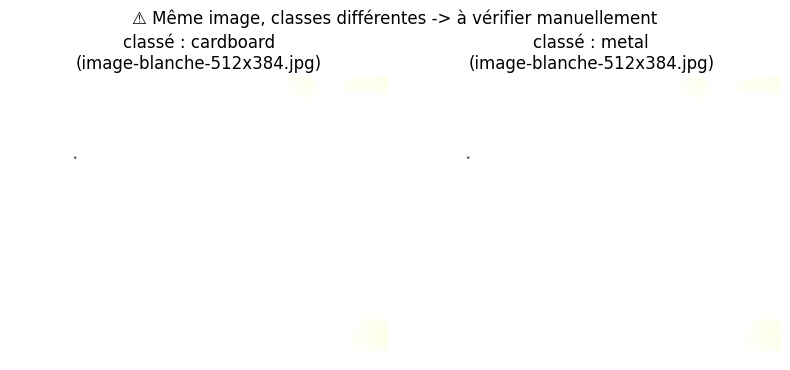

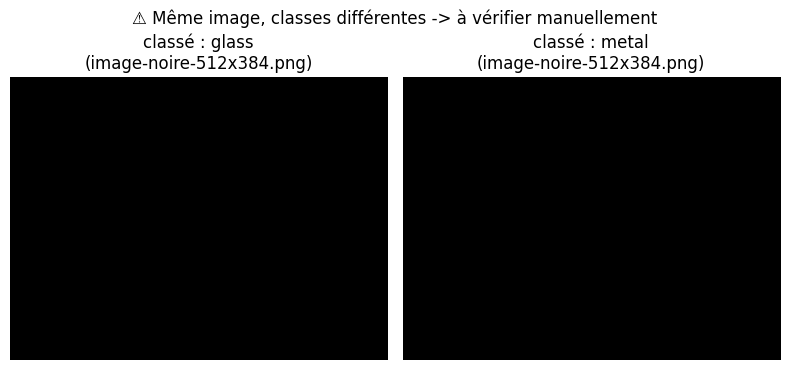

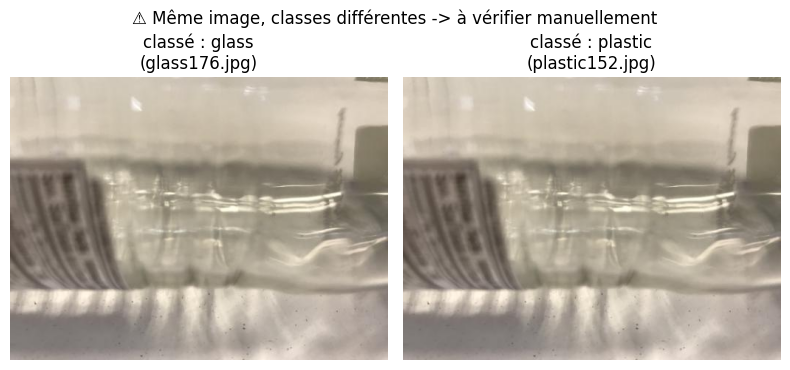

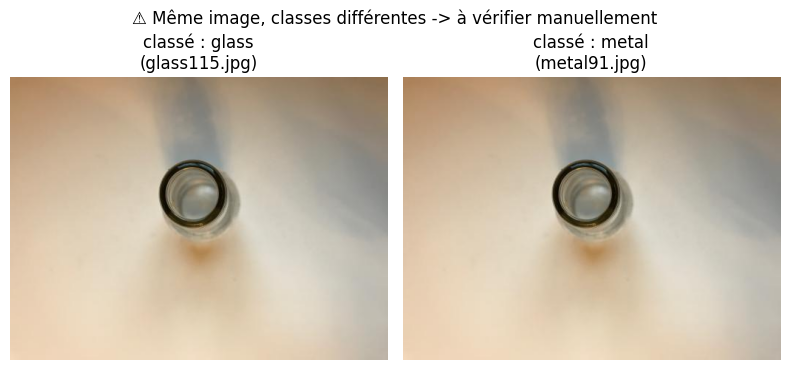

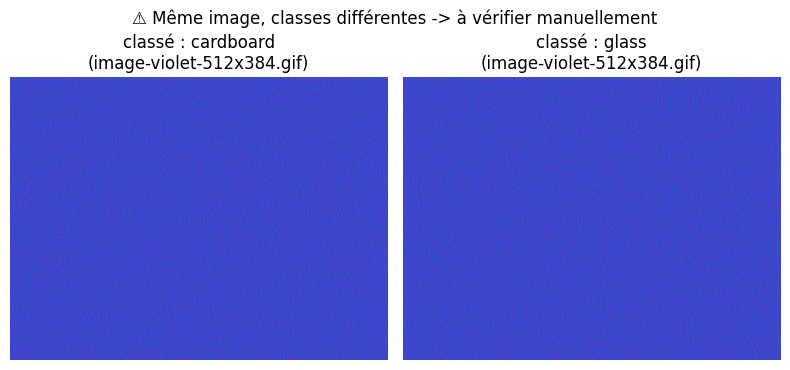

In [54]:
# Affichage côte à côte pour le contrôle visuel humain
for h in hashs_en_conflit:
    groupe = audit_valide[audit_valide["hash_pixels"] == h]
    fig, axes = plt.subplots(1, len(groupe), figsize=(4 * len(groupe), 4))
    for ax, (_, row) in zip(axes, groupe.iterrows()):
        img = Image.open(row["chemin"])
        ax.imshow(img)
        ax.set_title(f"classé : {row['classe']}\n({row['nom']})")
        ax.axis("off")
    plt.suptitle("⚠️ Même image, classes différentes -> à vérifier manuellement")
    plt.tight_layout()
    plt.show()

**Contrôle visuel :** en regardant ces images côte à côte, on distingue deux cas différents
dans notre dataset :
- des **images "factices" de test** (uni noir / uni blanc / uni violet) volontairement dupliquées
  dans plusieurs dossiers pour tester notre pipeline — ce ne sont pas de "vraies" erreurs de
  classement métier, juste des doublons techniques ;
- de **vraies photos de déchets** dupliquées entre deux classes différentes (ex. une photo présente
  à la fois dans `glass/` et dans `metal/`, ou dans `glass/` et `plastic/`) : celles-ci sont de
  véritables cas de mauvais classement qu'il faudrait, dans un vrai projet, faire trancher par un
  expert métier pour savoir laquelle des deux classes est la bonne.

**Décision retenue pour la suite :** comme ces images sont de toute façon des doublons, la stratégie
de dédoublonnage de la Partie 6 (ne garder qu'une seule copie par groupe) **résout automatiquement**
le problème : une seule des deux classes conflictuelles restera dans le dataset nettoyé. Ce n'est
pas une solution parfaite (on ne sait pas si la classe conservée est la bonne), mais c'est un
compromis raisonnable — à affiner par une vraie relecture humaine en
conditions réelles.

### Et pour les images qui ne sont PAS des doublons mais restent mal classées ?
Pour ce cas plus général (une photo unique, mais rangée dans le mauvais dossier dès le départ, sans
copie ailleurs), seul un contrôle visuel par échantillonnage permet de les repérer.

**Partie 8 : Analyser le déséquilibre des classes**

Déterminer le nombre d'images par classe

In [55]:
effectifs_classes = audit_valide["classe"].value_counts().reindex(CLASSES)
print("Nombre d'images par classe (dataset brut, avant nettoyage) :")
print(effectifs_classes)
print()
pourcentages = (effectifs_classes / effectifs_classes.sum() * 100).round(1)
print("En pourcentage :")
print(pourcentages)

Nombre d'images par classe (dataset brut, avant nettoyage) :
classe
cardboard    168
glass        187
metal        148
paper        251
plastic      223
trash         49
Name: count, dtype: int64

En pourcentage :
classe
cardboard    16.4
glass        18.2
metal        14.4
paper        24.5
plastic      21.7
trash         4.8
Name: count, dtype: float64


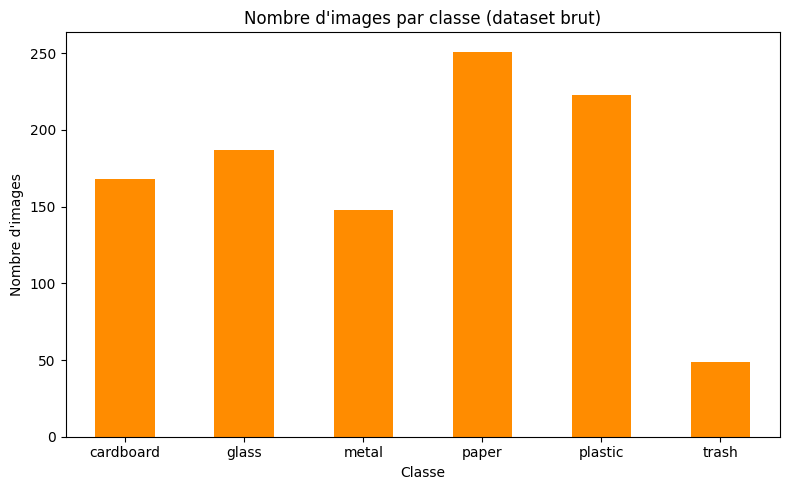

Ratio classe majoritaire / classe minoritaire : 5.12
Classe majoritaire : paper (251 images)
Classe minoritaire : trash (49 images)


In [56]:
plt.figure(figsize=(8, 5))
effectifs_classes.plot(kind="bar", color="darkorange")
plt.title("Nombre d'images par classe (dataset brut)")
plt.ylabel("Nombre d'images")
plt.xlabel("Classe")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ratio_desequilibre = effectifs_classes.max() / effectifs_classes.min()
print(f"Ratio classe majoritaire / classe minoritaire : {ratio_desequilibre:.2f}")
print(f"Classe majoritaire : {effectifs_classes.idxmax()} ({effectifs_classes.max()} images)")
print(f"Classe minoritaire : {effectifs_classes.idxmin()} ({effectifs_classes.min()} images)")

**Interprétation :** le dataset est clairement **déséquilibré** : certaines classes (comme
`paper` ou `plastic`) comptent plusieurs fois plus d'images que la classe `trash`, qui est nettement
sous-représentée. Un modèle entraîné tel quel aurait tendance à "négliger" cette classe minoritaire
(il obtiendrait déjà une bonne accuracy globale en la prédisant rarement). C'est précisément ce
déséquilibre qu'on va corriger avec de la **data augmentation ciblée** sur la classe minoritaire en
Partie 13.

**Export du rapport d'audit : `reports/audit_images.csv`**

Comme demandé dans l'énoncé, on synthétise tous les résultats de l'audit (Parties 1 à 8) dans un
fichier CSV récapitulatif, avec le nombre d'images concernées par chaque type de problème.

In [60]:
# On recalcule ici, de façon centralisée, tous les indicateurs demandés dans le CSV

nb_total = len(audit)
nb_corrompues = int(audit["corrompue"].sum())
nb_quasi_vides = int(audit_valide["quasi_vide"].sum())
nb_trop_petites = int(audit_valide["trop_petite"].sum())
nb_doublons_a_retirer = int(audit_valide["doublon_a_retirer"].sum())
nb_grayscale = int(audit_valide["grayscale_visuel"].sum())
nb_rgba = int((audit_valide["mode"] == "RGBA").sum())
nb_mal_classees = int(
    audit_valide[audit_valide["hash_pixels"].isin(hashs_en_conflit)].shape[0]
)

resume_audit = pd.DataFrame({
    "indicateur": [
        "Total d'images",
        "Images corrompues",
        "Images quasi vides",
        "Images trop petites (< 64x64)",
        "Doublons (copies à retirer)",
        "Images grayscale (visuellement, hors mode L/P)",
        "Images RGBA",
        "Images mal classées (doublons multi-classes détectés)",
    ],
    "nombre": [
        nb_total,
        nb_corrompues,
        nb_quasi_vides,
        nb_trop_petites,
        nb_doublons_a_retirer,
        nb_grayscale,
        nb_rgba,
        nb_mal_classees,
    ],
})

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
resume_audit.to_csv(REPORTS_DIR / "audit_images.csv", index=False)

print("Rapport exporté avec succès :", REPORTS_DIR / "audit_images.csv")
resume_audit

Rapport exporté avec succès : ..\reports\audit_images.csv


,indicateur,nombre
0,Total d'images,1032
1,Images corrompues,6
2,Images quasi vides,4
3,Images trop petites (< 64x64),13
4,Doublons (copies à retirer),15
5,"Images grayscale (visuellement, hors mode L/P)",17
6,Images RGBA,18
7,Images mal classées (doublons multi-classes dé...,10


Avant de passer aux transformations (redimensionnement, conversion RGB, normalisation), on prend
une décision claire : quelles images du dossier `raw/` vont réellement être copiées et transformées
dans `cleaned/` ?

**On exclut une image si elle est :**
- corrompue (Partie 2) — illisible, aucune transformation n'est possible ;
- quasi vide (Partie 3) — aucune information visuelle exploitable ;
- trop petite, < 64×64 (Partie 4) — pas assez de détails pour être utile après redimensionnement ;
- un doublon à retirer (Partie 6 / 7) — on garde une seule copie par contenu visuel identique,
  ce qui règle au passage une partie des conflits de classement détectés en Partie 7.

**On garde en revanche** les images RGBA, en palette (`P`) ou visuellement grayscale : elles seront
simplement **converties** en RGB standard (Partie 10), pas supprimées — leur contenu reste
parfaitement exploitable, il faut juste les uniformiser.

In [61]:
a_exclure = (
    audit_valide["corrompue"].fillna(False)
    | audit_valide["quasi_vide"].fillna(False)
    | audit_valide["trop_petite"].fillna(False)
    | audit_valide["doublon_a_retirer"].fillna(False)
)

# Les images corrompues n'existent que dans `audit` (elles n'ont pas de ligne dans audit_valide
# puisqu'on n'a pas pu les décoder) : on les rajoute explicitement à la liste des exclusions.
chemins_corrompus = set(audit[audit["corrompue"]]["chemin"])

audit_valide["a_conserver"] = ~a_exclure
images_conservees = audit_valide[audit_valide["a_conserver"]]

print(f"Images dans raw/ (total)         : {len(audit)}")
print(f"  dont corrompues (exclues)      : {len(chemins_corrompus)}")
print(f"  dont quasi vides (exclues)     : {int(audit_valide['quasi_vide'].sum())}")
print(f"  dont trop petites (exclues)    : {int(audit_valide['trop_petite'].sum())}")
print(f"  dont doublons à retirer        : {int(audit_valide['doublon_a_retirer'].sum())}")
print(f"Images conservées pour cleaned/  : {len(images_conservees)}")
print()
print("Répartition par classe après nettoyage :")
print(images_conservees["classe"].value_counts().reindex(CLASSES))

Images dans raw/ (total)         : 1032
  dont corrompues (exclues)      : 6
  dont quasi vides (exclues)     : 4
  dont trop petites (exclues)    : 13
  dont doublons à retirer        : 15
Images conservées pour cleaned/  : 996

Répartition par classe après nettoyage :
classe
cardboard    164
glass        181
metal        139
paper        245
plastic      218
trash         49
Name: count, dtype: int64


On travaillera à partir de maintenant sur `images_conservees` : c'est la liste des chemins
`raw/...` qui vont être lus, transformés, puis sauvegardés dans `cleaned/`.

**Partie 9 – Redimensionnement**

Redimensionner toutes les images à 224 × 224.
NB : Redimensionnement avec conservation des proportions et ajout éventuel de padding

### Pourquoi 224×224 ?
C'est la taille d'entrée standard utilisée par de nombreux modèles pré-entraînés de classification
d'images (ResNet, VGG, MobileNet...). Uniformiser toutes nos images à cette taille permettra de
les réutiliser facilement avec ces architectures.

### Pourquoi "conserver les proportions" plutôt qu'un simple `resize()` ?
Si on utilisait directement `img.resize((224, 224))` sur une image de 512×384 (ratio 4:3), l'image
serait **déformée** : les objets deviendraient plus larges ou plus étroits qu'en réalité (un
carton rectangulaire pourrait apparaître carré). Cette déformation ajoute un biais artificiel que le
modèle pourrait mal interpréter.

### La solution : `thumbnail()` + `padding`
1. `img.thumbnail((224, 224))` redimensionne l'image en **conservant son ratio largeur/hauteur**,
   de façon à ce qu'elle tienne entièrement dans un carré de 224×224 (l'image résultante est donc
   ≤ 224 dans les deux dimensions, mais pas forcément exactement 224×224).
2. On crée ensuite un nouveau canevas carré 224×224 rempli d'une couleur unie (le "padding", ici du
   noir), et on **colle** (`.paste()`) l'image redimensionnée bien au centre de ce canevas.

C'est la technique dite du **"letterboxing"** (comme les bandes noires en haut/bas d'un film au
mauvais format sur un écran).

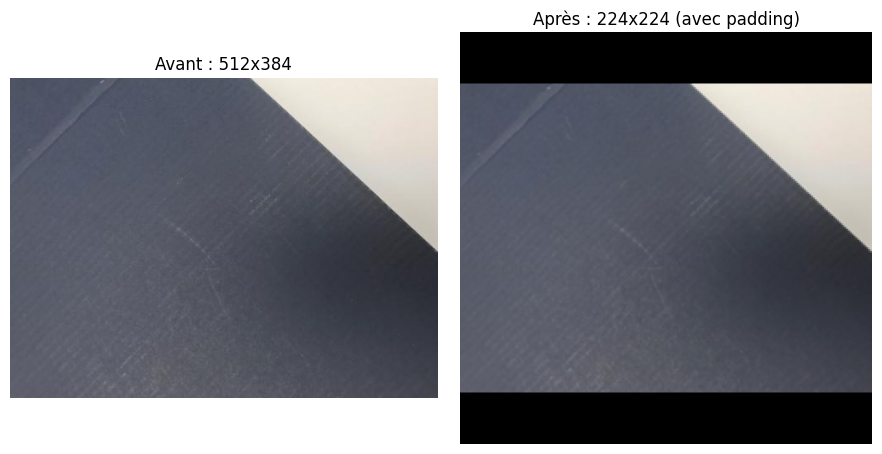

In [66]:
TAILLE_CIBLE = (224, 224)
COULEUR_PADDING = (0, 0, 0)  # noir ; on pourrait aussi choisir du blanc (255,255,255) ou du gris

def redimensionner_avec_padding(img, taille_cible=TAILLE_CIBLE, couleur=COULEUR_PADDING):
    """
    Redimensionne une image PIL pour qu'elle tienne dans taille_cible SANS déformation,
    puis la centre sur un fond de couleur unie de taille exactement taille_cible.
    """
    img_redimensionnee = img.copy()

    img_redimensionnee.thumbnail(taille_cible, Image.LANCZOS)

    canevas = Image.new("RGB", taille_cible, couleur)

    decalage_x = (taille_cible[0] - img_redimensionnee.width) // 2
    decalage_y = (taille_cible[1] - img_redimensionnee.height) // 2

    canevas.paste(img_redimensionnee, (decalage_x, decalage_y))

    return canevas


img_demo = Image.open(RAW_DIR / "cardboard" / "cardboard15.jpg").convert("RGB")
img_demo_redim = redimensionner_avec_padding(img_demo)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img_demo)
axes[0].set_title(f"Avant : {img_demo.size[0]}x{img_demo.size[1]}")
axes[0].axis("off")
axes[1].imshow(img_demo_redim)
axes[1].set_title(f"Après : {img_demo_redim.size[0]}x{img_demo_redim.size[1]} (avec padding)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

On voit bien les bandes noires ajoutées en haut et en bas (ou à gauche/droite selon le ratio
d'origine) : l'objet photographié n'est absolument pas déformé, contrairement à ce qu'aurait
produit un `resize()` classique.

**Comparons rapidement avec un `resize()` classique (sans padding), pour bien voir la différence :**

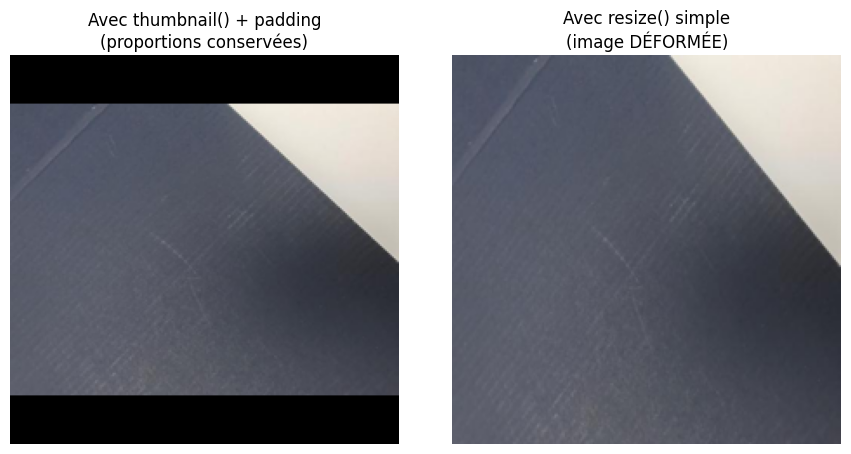

In [67]:
img_demo_deforme = img_demo.resize(TAILLE_CIBLE)  # PAS de conservation du ratio !

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img_demo_redim)
axes[0].set_title("Avec thumbnail() + padding\n(proportions conservées)")
axes[0].axis("off")
axes[1].imshow(img_demo_deforme)
axes[1].set_title("Avec resize() simple\n(image DÉFORMÉE)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

**On applique maintenant cette transformation à toutes les images conservées, et on les
sauvegarde dans `data/cleaned/<classe>/`.**

In [68]:
# On (re)crée l'arborescence de sortie : un sous-dossier par classe dans cleaned/
for classe in CLASSES:
    (CLEANED_DIR / classe).mkdir(parents=True, exist_ok=True)

chemins_cleaned = {}  # on garde une trace : chemin raw -> chemin cleaned, pour les étapes suivantes

for _, row in images_conservees.iterrows():
    img = Image.open(row["chemin"]).convert("RGB")
    img_redim = redimensionner_avec_padding(img)

    # On normalise aussi l'extension de sortie en .jpg, pour repartir sur un format homogène
    nom_sortie = Path(row["nom"]).stem + ".jpg"
    chemin_sortie = CLEANED_DIR / row["classe"] / nom_sortie

    img_redim.save(chemin_sortie, "JPEG", quality=95)
    chemins_cleaned[row["chemin"]] = str(chemin_sortie)

print(f"{len(chemins_cleaned)} images redimensionnées et sauvegardées dans {CLEANED_DIR}/")

996 images redimensionnées et sauvegardées dans ..\data\cleaned/


**Partie 10 : Uniformisation des canaux**

Convertir toutes les images en RGB

```python
img = Image.open(row["chemin"]).convert("RGB")
``` 
c'est cette fonction qui a permit de faire la conversion en RGB donc la question est répondu bien avant a la question précedente

**Pourquoi avoir fait la conversion RGB *avant* le redimensionnement, plutôt qu'après ?**
Parce que `Image.new("RGB", ...)` (utilisé dans notre fonction de padding) crée un canevas en mode
RGB. Si on lui avait collé une image encore en RGBA ou en mode palette (`P`) dessus, Pillow aurait
pu lever une erreur ou produire un résultat incorrect (le canal alpha ne "sait pas" comment se
fondre dans un canevas qui n'a pas de canal alpha). Convertir en RGB **en tout premier**, avant
toute autre opération, est donc la façon la plus sûre de procéder.

Vérifions que la conversion a bien fonctionné sur l'ensemble du dataset nettoyé.

In [72]:

from collections import Counter, defaultdict

modes_dans_cleaned = Counter()
canaux_dans_cleaned = Counter()

for chemin in CLEANED_DIR.glob("*/*.jpg"):
    with Image.open(chemin) as img:
        modes_dans_cleaned[img.mode] += 1
        canaux_dans_cleaned[len(img.getbands())] += 1

print("Modes présents dans cleaned/ :", dict(modes_dans_cleaned))
print("Nombres de canaux présents dans cleaned/ :", dict(canaux_dans_cleaned))
assert set(modes_dans_cleaned.keys()) == {"RGB"}, "Certaines images ne sont pas en RGB !"
print("Toutes les images de cleaned/ sont bien en mode RGB (3 canaux). ✔")

Modes présents dans cleaned/ : {'RGB': 996}
Nombres de canaux présents dans cleaned/ : {3: 996}
Toutes les images de cleaned/ sont bien en mode RGB (3 canaux). ✔


**Ce qui s'est passé concrètement pour chaque type de mode d'origine, via `.convert("RGB")` :**
- Une image déjà en **RGB** : aucun changement, elle reste identique.
- Une image en **RGBA** (4 canaux) : le canal de transparence (alpha) est supprimé — les pixels
  transparents deviennent simplement opaques, en gardant leur couleur R/G/B sous-jacente.
- Une image en **`P`** (palette, typiquement les GIF) : chaque indice de pixel est remplacé par la
  vraie couleur RGB qu'il représentait dans la palette.
- Une image en **`L`** (niveaux de gris, 1 canal) : la valeur de gris est dupliquée sur les 3
  canaux R, G et B (un gris de valeur 128 devient (128, 128, 128)) — l'image reste visuellement
  identique, mais est désormais structurellement compatible avec toutes les autres.

**Partie 11 – Mise à l'échelle des pixels**

Normaliser les valeurs des pixels de toutes les images

### Pourquoi normaliser ?
On l'a vu en Pillow 101 : `np.array(img)` donne des valeurs de pixels en `uint8`, entre **0 et
255**. C'est parfait pour l'affichage, mais pas idéal pour entraîner un réseau de neurones : des
algorithmes d'optimisation comme la descente de gradient convergent generalement mieux et plus vite
quand les valeurs d'entrée sont **petites et centrées autour de 0**, plutôt que de grands entiers
positifs comme 0–255. On "met donc à l'échelle" ces valeurs, typiquement dans l'intervalle `[0, 1]`
(division par 255) ou `[-1, 1]`.

### Point important : on ne sauvegarde PAS d'images normalisées sur le disque
Un fichier image (`.jpg`, `.png`...) est conçu pour stocker des pixels en **entiers 0–255** ; il n'existe
pas de format d'image standard pour stocker des pixels flottants entre 0.0 et 1.0. Sauvegarder une
image normalisée reviendrait donc soit à la re-convertir en 0–255 (ce qui annule la normalisation
et ne sert à rien), soit à utiliser un format non standard (peu pratique pour la suite).

**La bonne pratique**, qu'on suit ici, est de :
1. garder les fichiers du dataset `cleaned/` en JPEG classique, pixels 0–255 (ce qu'on a déjà fait
   en Partie 9-10) ;
2. appliquer la normalisation **à la volée**, au moment où les images sont chargées pour
   l'entraînement du modèle (par exemple via une couche `Rescaling(1./255)` de Keras, ou l'argument
   `rescale=1./255` d'un générateur de données comme on le verra en Partie 13).

On démontre malgré tout ci-dessous, **sur un exemple en mémoire**, comment cette normalisation
fonctionne concrètement — c'est exactement ce que fait Keras "sous le capot".

In [ ]:
chemin_exemple = next(CLEANED_DIR.glob("*/*.jpg"))
img = Image.open(chemin_exemple)

arr_brut = np.array(img)
print("--- Avant normalisation ---")
print("dtype :", arr_brut.dtype)
print("min / max :", arr_brut.min(), "/", arr_brut.max())
print()


arr_normalise = arr_brut.astype(np.float32) / 255.0

print("--- Après normalisation [0, 1] ---")
print("dtype :", arr_normalise.dtype)
print("min / max :", arr_normalise.min(), "/", arr_normalise.max())

--- Avant normalisation ---
dtype : uint8
min / max : 0 / 252

--- Après normalisation [0, 1] ---
dtype : float32
min / max : 0.0 / 0.9882353


--- Après normalisation [-1, 1] ---
min / max : -1.0 / 0.9764706


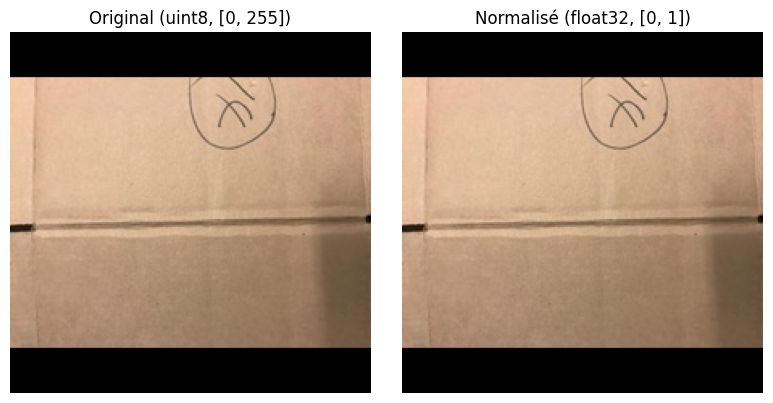

In [ ]:
arr_normalise_centre = (arr_brut.astype(np.float32) / 127.5) - 1.0

print("--- Après normalisation [-1, 1] ---")
print("min / max :", arr_normalise_centre.min(), "/", arr_normalise_centre.max())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(arr_brut)
axes[0].set_title("Original (uint8, [0, 255])")
axes[0].axis("off")
axes[1].imshow(arr_normalise)
axes[1].set_title("Normalisé (float32, [0, 1])")
axes[1].axis("off")
plt.tight_layout()
plt.show()

**Ce qu'il faut retenir :** la normalisation ne change **jamais** ce que représente l'image —
seulement l'échelle numérique de ses pixels. On garde cette étape "en mémoire, à la volée" et on
l'appliquera concrètement au moment de charger les données pour l'entraînement (Partie 13, via
Keras).

**Partie 12 : Découpage Train/Validation/Test**

Découper le dataset nettoyé (cleaned) en trois sous-ensembles : train, validation et test

### Pourquoi 3 ensembles et pas juste train/test comme pour des données tabulaires ?
- **train** : les images sur lesquelles le modèle apprend réellement (ajuste ses poids).
- **validation** : utilisé PENDANT l'entraînement pour surveiller si le modèle généralise bien
  (et ajuster des hyperparamètres, décider quand arrêter l'entraînement...), sans jamais influencer
  directement les poids du modèle.
- **test** : gardé complètement de côté, utilisé **une seule fois à la toute fin**, pour évaluer la
  performance réelle du modèle sur des données qu'il n'a jamais vues, ni pour apprendre ni pour
  ajuster quoi que ce soit.

On choisit une répartition classique **70 % train / 15 % validation / 15 % test**, en conservant
les proportions de classes dans chaque sous-ensemble (`stratify`) — exactement comme pour les
données tabulaires — pour que la classe minoritaire `trash` soit bien représentée dans les 3
ensembles.

In [78]:
# On construit d'abord un DataFrame listant tous les chemins de cleaned/ avec leur classe
fichiers_cleaned = []
for classe in CLASSES:
    for chemin in sorted((CLEANED_DIR / classe).glob("*.jpg")):
        fichiers_cleaned.append({"chemin": chemin, "classe": classe})

df_cleaned = pd.DataFrame(fichiers_cleaned)
print(f"Nombre total d'images dans cleaned/ : {len(df_cleaned)}")
print(df_cleaned["classe"].value_counts().reindex(CLASSES))

Nombre total d'images dans cleaned/ : 996
classe
cardboard    164
glass        181
metal        139
paper        245
plastic      218
trash         49
Name: count, dtype: int64


In [79]:
from sklearn.model_selection import train_test_split
# Étape 1 : on sépare d'abord train (70%) vs "reste" (30%)
df_train, df_reste = train_test_split(
    df_cleaned,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_cleaned["classe"],
)

# Étape 2 : on coupe le "reste" (30%) en deux moitiés égales -> validation (15%) et test (15%)
df_val, df_test = train_test_split(
    df_reste,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=df_reste["classe"],
)

print(f"Train      : {len(df_train)} images ({len(df_train)/len(df_cleaned)*100:.1f}%)")
print(f"Validation : {len(df_val)} images ({len(df_val)/len(df_cleaned)*100:.1f}%)")
print(f"Test       : {len(df_test)} images ({len(df_test)/len(df_cleaned)*100:.1f}%)")

Train      : 697 images (70.0%)
Validation : 149 images (15.0%)
Test       : 150 images (15.1%)


In [80]:
# Vérification : les proportions de classes sont-elles bien conservées dans les 3 ensembles ?
comparaison = pd.DataFrame({
    "cleaned (100%)": df_cleaned["classe"].value_counts(normalize=True) * 100,
    "train": df_train["classe"].value_counts(normalize=True) * 100,
    "validation": df_val["classe"].value_counts(normalize=True) * 100,
    "test": df_test["classe"].value_counts(normalize=True) * 100,
}).round(1).reindex(CLASSES)

comparaison

,cleaned (100%),train,validation,test
classe,,,,
cardboard,16.5,16.5,16.1,16.7
glass,18.2,18.2,18.1,18.0
metal,14.0,13.9,14.1,14.0
paper,24.6,24.5,24.8,24.7
plastic,21.9,22.0,21.5,22.0
trash,4.9,4.9,5.4,4.7


Les pourcentages sont quasiment identiques d'une colonne à l'autre : la stratification a bien
fonctionné.

**Organisation physique des dossiers :** pour pouvoir utiliser directement ces ensembles avec des
outils comme `keras.utils.image_dataset_from_directory` (qui attend une arborescence
`dossier/classe/image.jpg`), on **copie physiquement** les fichiers dans une nouvelle arborescence
`cleaned/train/<classe>/`, `cleaned/val/<classe>/`, `cleaned/test/<classe>/`.

In [81]:
import shutil


def copier_vers_split(df_split, nom_split):
    for classe in CLASSES:
        (CLEANED_DIR / nom_split / classe).mkdir(parents=True, exist_ok=True)

    for _, row in df_split.iterrows():
        destination = CLEANED_DIR / nom_split / row["classe"] / row["chemin"].name
        shutil.copyfile(row["chemin"], destination)


copier_vers_split(df_train, "train")
copier_vers_split(df_val, "val")
copier_vers_split(df_test, "test")

print("Répartition physique des dossiers créée :")
for split in ["train", "val", "test"]:
    total_split = sum(1 for _ in (CLEANED_DIR / split).glob("*/*.jpg"))
    print(f"  cleaned/{split}/ : {total_split} images")

Répartition physique des dossiers créée :
  cleaned/train/ : 697 images
  cleaned/val/ : 149 images
  cleaned/test/ : 150 images


**Partie 13 : Data Augmentation**

1) A l’aide de Keras, appliquer à la classe minoritaire de la « data augmentation » en utilisant des
transformations comme rotation légère, retournement horizontal, zoom, translation, variation
de luminosité, variation de contraste, légère variation de couleur, …

la classe `trash` est nettement sous-représentée par rapport aux autres.
Plutôt que de collecter de nouvelles photos (coûteux), on peut **générer artificiellement de
nouvelles variantes** des images existantes de cette classe, en leur appliquant de légères
transformations aléatoires réalistes : légère rotation, retournement horizontal, zoom, translation,
variation de luminosité...

### Pourquoi ces transformations ont-elles du sens visuellement ?
Un déchet photographié peut apparaître sous un angle légèrement différent, avec un éclairage
légèrement différent, ou décentré dans le cadre — la classe réelle de l'objet ne change absolument
pas pour autant. En apprenant sur ces variantes, le modèle devient plus **robuste** à ces
variations naturelles, plutôt que d'apprendre "par cœur" les quelques photos originales
(ce qu'on appelle le sur-apprentissage / overfitting).

In [82]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.6.0-cp313-cp313-win_amd64.whl.metadata (8.8 kB)
  Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.1.0-py3-none-an

In [84]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img

# ImageDataGenerator : un générateur Keras qui applique des transformations aléatoires à la volée.
# Chaque paramètre correspond à un TYPE de transformation, avec son AMPLITUDE maximale :
generateur_augmentation = ImageDataGenerator(
    rotation_range=15,          # rotation aléatoire jusqu'à +/- 15 degrés
    width_shift_range=0.1,      # translation horizontale aléatoire jusqu'à 10% de la largeur
    height_shift_range=0.1,     # translation verticale aléatoire jusqu'à 10% de la hauteur
    zoom_range=0.15,            # zoom avant/arrière aléatoire jusqu'à 15%
    horizontal_flip=True,       # retournement horizontal (miroir) aléatoire
    brightness_range=[0.8, 1.2],# variation de luminosité : entre 80% et 120% de l'originale
    fill_mode="nearest",        # comment remplir les nouveaux pixels créés par rotation/translation
                                 # (ex: un coin qui apparaît après rotation) : "nearest" recopie
                                 # la couleur du pixel valide le plus proche.
)

print("Générateur de data augmentation configuré.")

Générateur de data augmentation configuré.


**On garde volontairement l'amplitude des transformations modérée** (15° de rotation max, 15%
de zoom max...) : des transformations trop violentes produiraient des images irréalistes qui
pourraient au contraire dégrader l'apprentissage (ex. un carton pivoté à 90° et fortement zoomé
pourrait ne plus du tout ressembler à un carton typique tel qu'il apparaîtra en usage réel).

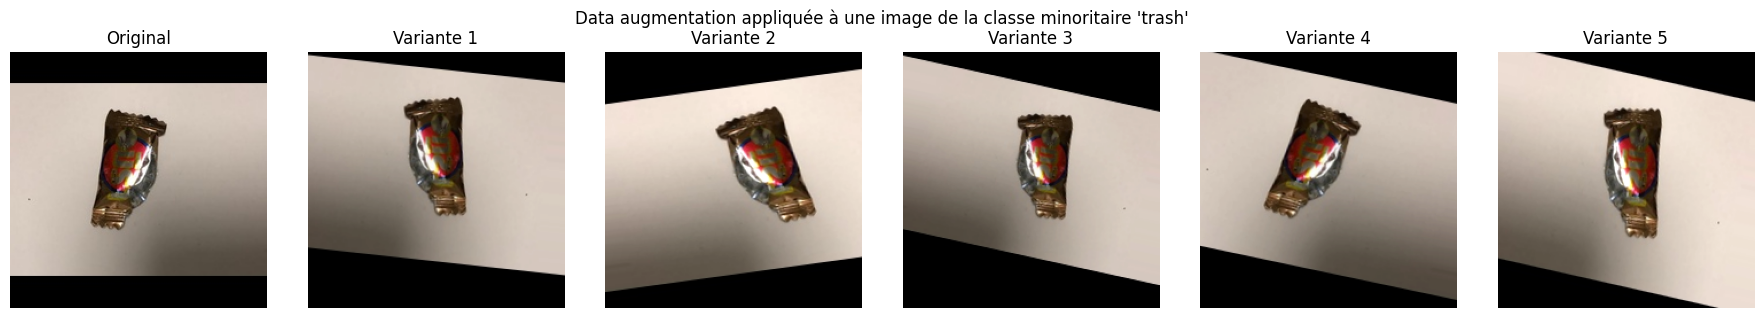

In [85]:
chemin_trash_exemple = next((CLEANED_DIR / "train" / "trash").glob("*.jpg"))
img_originale = Image.open(chemin_trash_exemple)

arr_originale = img_to_array(img_originale)

arr_originale_batch = np.expand_dims(arr_originale, axis=0)

iterateur = generateur_augmentation.flow(arr_originale_batch, batch_size=1)

fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
axes[0].imshow(img_originale)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 6):
    lot_augmente = next(iterateur)         # génère UN nouveau lot (ici : 1 image transformée)
    image_augmentee = array_to_img(lot_augmente[0])   # reconversion tableau -> image Pillow affichable
    axes[i].imshow(image_augmentee)
    axes[i].set_title(f"Variante {i}")
    axes[i].axis("off")

plt.suptitle("Data augmentation appliquée à une image de la classe minoritaire 'trash'")
plt.tight_layout()
plt.show()

Chaque "variante" est une version légèrement différente de la même image d'origine — un objet
identique, mais jamais exactement reproduit à l'identique. On génère maintenant suffisamment de
variantes pour rééquilibrer la classe `trash` avec les autres classes, **uniquement dans le dossier
`train/`**.

In [86]:
effectifs_train = df_train["classe"].value_counts().reindex(CLASSES)
print("Effectifs dans train/ avant augmentation :")
print(effectifs_train)

classe_minoritaire = effectifs_train.idxmin()
objectif = int(effectifs_train.median())   # on vise la médiane des autres classes, un choix raisonnable
nb_a_generer = max(0, objectif - effectifs_train[classe_minoritaire])

print(f"\nClasse minoritaire : '{classe_minoritaire}' ({effectifs_train[classe_minoritaire]} images)")
print(f"Objectif visé : {objectif} images -> {nb_a_generer} images à générer par augmentation")

Effectifs dans train/ avant augmentation :
classe
cardboard    115
glass        127
metal         97
paper        171
plastic      153
trash         34
Name: count, dtype: int64

Classe minoritaire : 'trash' (34 images)
Objectif visé : 121 images -> 87 images à générer par augmentation


In [87]:
dossier_train_minoritaire = CLEANED_DIR / "train" / classe_minoritaire
images_source = sorted(dossier_train_minoritaire.glob("*.jpg"))

compteur_generees = 0
i = 0
while compteur_generees < nb_a_generer:
    # On boucle sur les images sources disponibles, en repartant du début si nécessaire
    chemin_source = images_source[i % len(images_source)]
    img = Image.open(chemin_source)
    arr = img_to_array(img)
    arr_batch = np.expand_dims(arr, axis=0)

    it = generateur_augmentation.flow(arr_batch, batch_size=1, seed=RANDOM_STATE + compteur_generees)
    lot_augmente = next(it)
    image_augmentee = array_to_img(lot_augmente[0])

    nom_sortie = f"{chemin_source.stem}_aug{compteur_generees}.jpg"
    image_augmentee.save(dossier_train_minoritaire / nom_sortie, "JPEG", quality=95)

    compteur_generees += 1
    i += 1

print(f"{compteur_generees} images augmentées générées et ajoutées à {dossier_train_minoritaire}")

87 images augmentées générées et ajoutées à ..\data\cleaned\train\trash


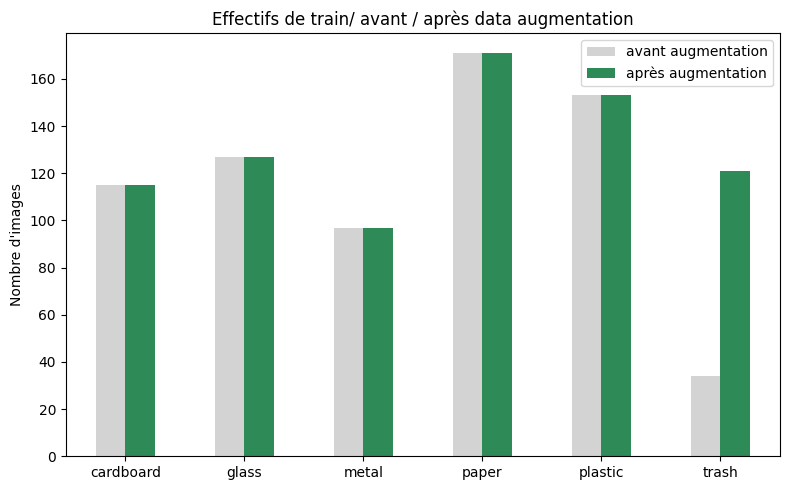

,avant augmentation,après augmentation
cardboard,115,115
glass,127,127
metal,97,97
paper,171,171
plastic,153,153
trash,34,121


In [88]:
effectifs_train_apres = pd.Series(
    {classe: len(list((CLEANED_DIR / "train" / classe).glob("*.jpg"))) for classe in CLASSES}
).reindex(CLASSES)

comparaison_augmentation = pd.DataFrame({
    "avant augmentation": effectifs_train,
    "après augmentation": effectifs_train_apres,
})
comparaison_augmentation.plot(kind="bar", figsize=(8, 5), color=["lightgray", "seagreen"])
plt.title("Effectifs de train/ avant / après data augmentation")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

comparaison_augmentation